In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('tips')


In [52]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# *Task 1 — Distribusi Tip*

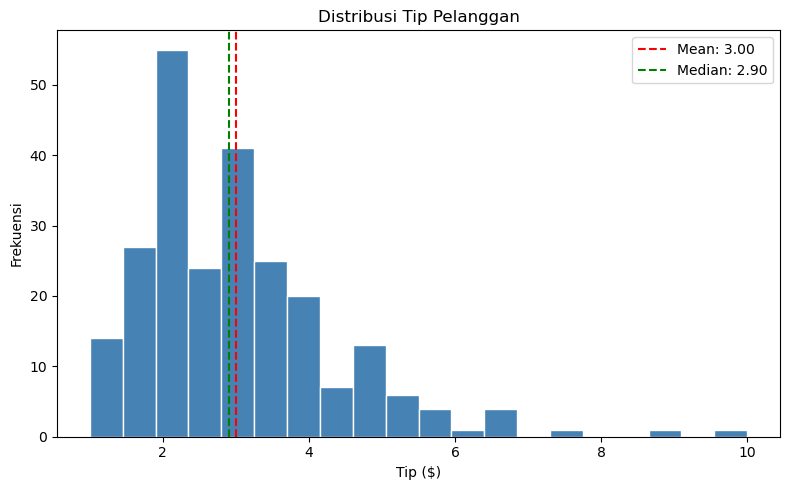

In [43]:
mean_tip = df['tip'].mean()
median_tip = df['tip'].median()

plt.figure(figsize=(8, 5))
plt.hist(df['tip'], bins=20, color='steelblue', edgecolor='white')
plt.axvline(mean_tip, color='red', linestyle='--', label=f'Mean: {mean_tip:.2f}')
plt.axvline(median_tip, color='green', linestyle='--', label=f'Median: {median_tip:.2f}')
plt.title('Distribusi Tip Pelanggan')
plt.xlabel('Tip ($)')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()

D:\Users\bsi80274\AppData\Local\Temp\ipykernel_30480\773205429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day', y='tip', order=day_order, palette='pastel')


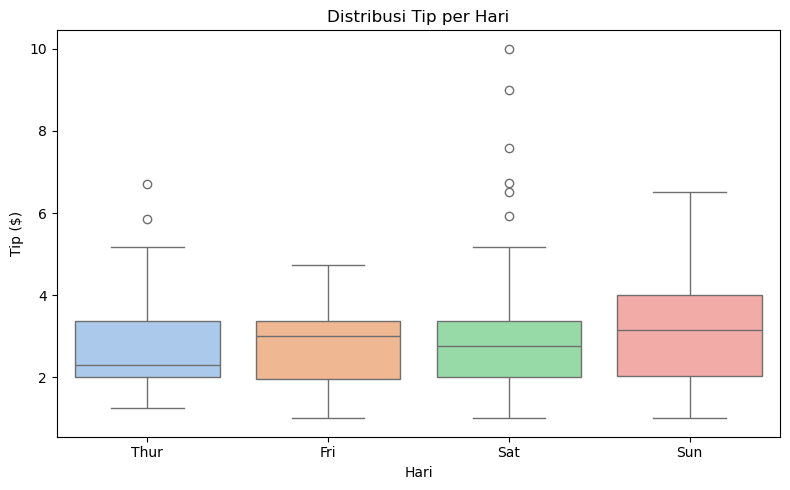

In [44]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='day', y='tip', order=day_order, palette='pastel')
plt.title('Distribusi Tip per Hari')
plt.xlabel('Hari')
plt.ylabel('Tip ($)')
plt.tight_layout()
plt.show()

**Analisis Task 1:**

Distribusi tip terlihat right-skewed — mayoritas pelanggan memberi tip di kisaran $1–$4, tapi ada beberapa yang memberi tip jauh lebih tinggi. Ini terlihat dari mean ($2.99) yang sedikit lebih tinggi dari median ($2.90).

Hari Sabtu dan Minggu punya lebih banyak outlier dibanding Kamis dan Jumat, kemungkinan karena lebih ramai dan ada pelanggan yang memberi tip sangat besar.

# *Task 2 — Hubungan Antar Variabel Numerik*

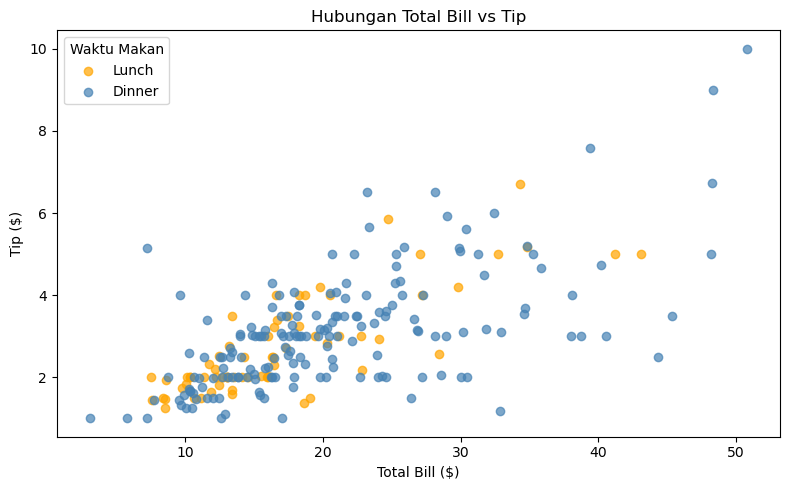

In [45]:
plt.figure(figsize=(8, 5))
colors = {'Lunch': 'orange', 'Dinner': 'steelblue'}
for time, group in df.groupby('time'):
    plt.scatter(group['total_bill'], group['tip'], label=time, alpha=0.7, color=colors[time])

plt.title('Hubungan Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend(title='Waktu Makan')
plt.tight_layout()
plt.show()

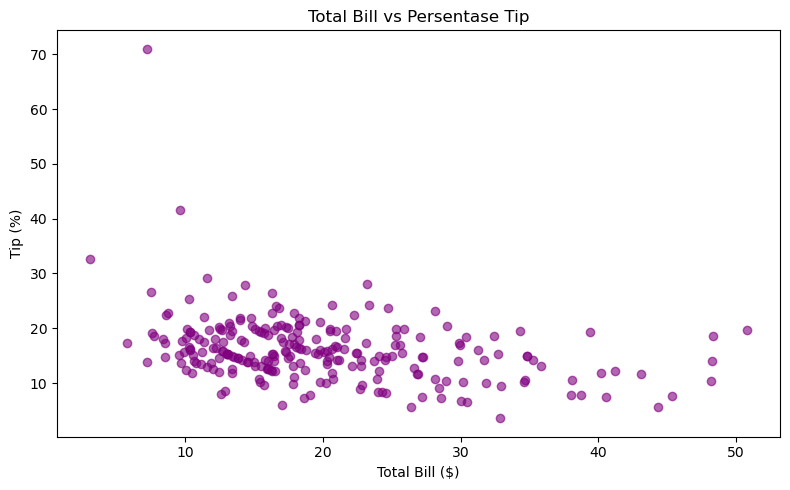

In [46]:
df['tip_pct'] = df['tip'] / df['total_bill'] * 100

plt.figure(figsize=(8, 5))
plt.scatter(df['total_bill'], df['tip_pct'], alpha=0.6, color='purple')
plt.title('Total Bill vs Persentase Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip (%)')
plt.tight_layout()
plt.show()

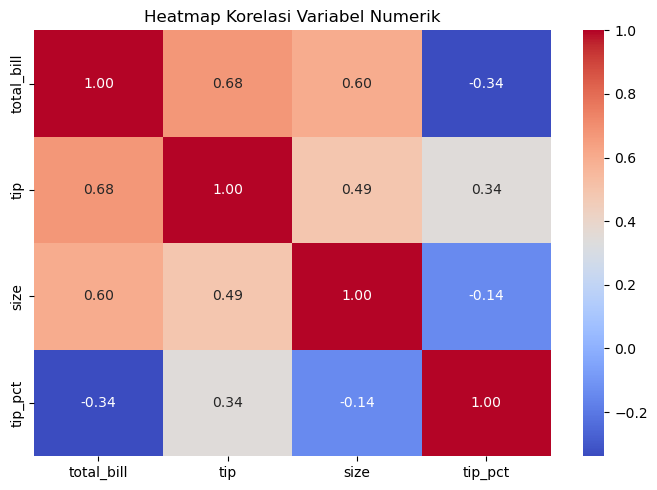

In [47]:
corr = df[['total_bill', 'tip', 'size', 'tip_pct']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

**Analisis Task 2:**

Scatter plot total_bill vs tip_pct menunjukkan tren negatif — pelanggan dengan tagihan lebih besar cenderung memberi persentase tip yang lebih rendah. Dari heatmap, korelasi total_bill dan tip_pct adalah negatif, sedangkan total_bill dan tip sendiri berkorelasi positif kuat (~0.68).

# *Task 3 — Perbandingan Antar Kategori*

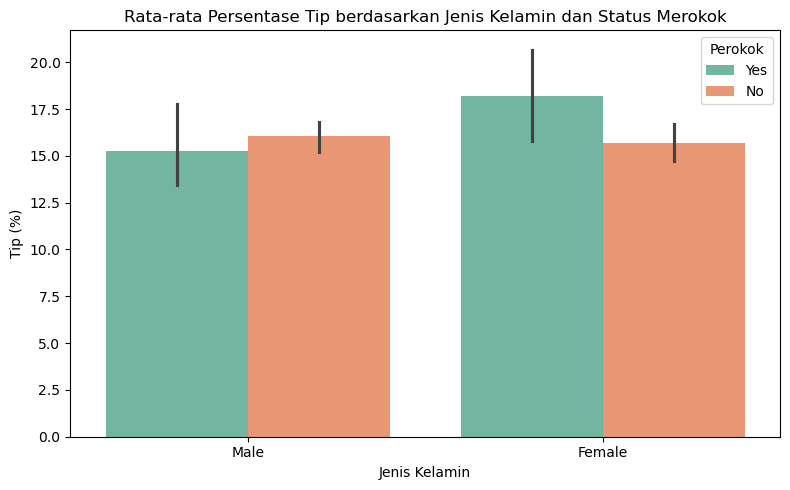

In [48]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='sex', y='tip_pct', hue='smoker', palette='Set2')
plt.title('Rata-rata Persentase Tip berdasarkan Jenis Kelamin dan Status Merokok')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Tip (%)')
plt.legend(title='Perokok')
plt.tight_layout()
plt.show()

D:\Users\bsi80274\AppData\Local\Temp\ipykernel_30480\1000036690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='tip', ax=axes[0], palette='pastel')
D:\Users\bsi80274\AppData\Local\Temp\ipykernel_30480\1000036690.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='tip', ax=axes[1], palette='pastel')


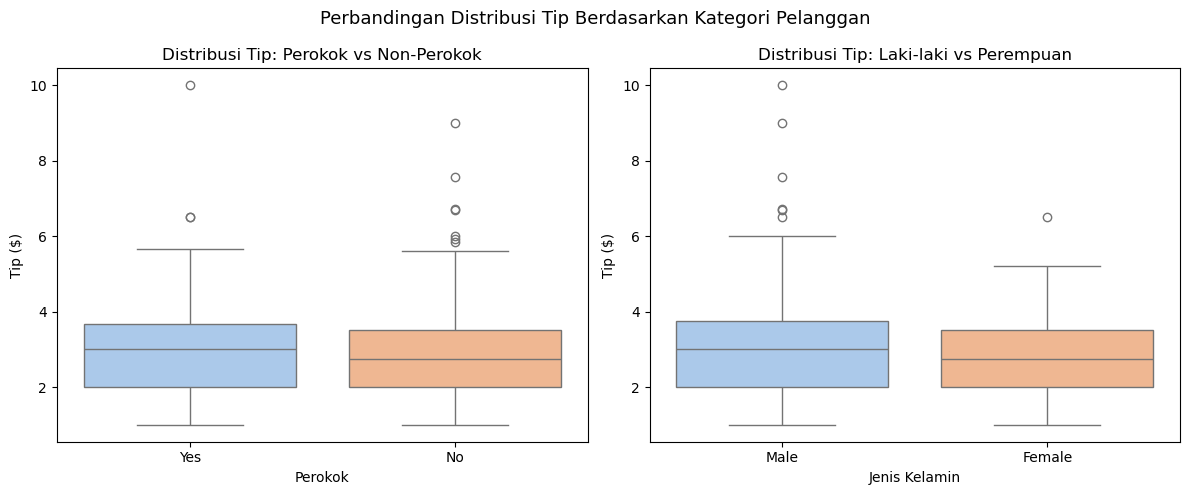

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='smoker', y='tip', ax=axes[0], palette='pastel')
axes[0].set_title('Distribusi Tip: Perokok vs Non-Perokok')
axes[0].set_xlabel('Perokok')
axes[0].set_ylabel('Tip ($)')

sns.boxplot(data=df, x='sex', y='tip', ax=axes[1], palette='pastel')
axes[1].set_title('Distribusi Tip: Laki-laki vs Perempuan')
axes[1].set_xlabel('Jenis Kelamin')
axes[1].set_ylabel('Tip ($)')

fig.suptitle('Perbandingan Distribusi Tip Berdasarkan Kategori Pelanggan', fontsize=13)
plt.tight_layout()
plt.show()

# *Task 4 — Narasi Visual*

**Faktor yang Berkaitan dengan Tip Tinggi**

Berdasarkan visualisasi yang telah dibuat, total tagihan adalah faktor paling kuat yang berkaitan dengan jumlah tip — seperti terlihat di scatter plot Task 2, semakin besar tagihan maka semakin besar pula tip yang diberikan. Selain itu, waktu makan juga berpengaruh: pelanggan Dinner cenderung memberi tip lebih besar dibanding Lunch (terlihat di scatter plot Task 2 dengan warna berbeda). Faktor perokok dan jenis kelamin tidak menunjukkan perbedaan yang terlalu mencolok berdasarkan boxplot di Task 3, meski perokok pria punya sebaran tip yang lebih lebar.

**Rekomendasi untuk Manajer:**

Fokuskan program insentif staf pada shift makan malam (Dinner), terutama di hari Sabtu dan Minggu, karena pelanggan di waktu tersebut cenderung memberi tip lebih tinggi. Staf yang melayani meja dengan tagihan besar perlu diprioritaskan karena memiliki potensi tip terbesar.